## Example from the introduction

In [1]:
# required modules (under Anaconda use: > conda install -c conda-forge <package>)
if False: # (skip if already installed)
    !pip install lark-parser
    !pip install linear-tree
    !pip install pydot
    !pip install pydotplus
    !pip install hopsy
    !pip install janus-swi
    # download and install SWI Prolog from https://www.swi-prolog.org/download/stable

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# standard imports
import os
import sys
import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Using janus - set SWI Prolog home
SWI_HOME = r"C:\Program Files\swipl"
os.environ["SWI_HOME_DIR"] = SWI_HOME
os.add_dll_directory(os.path.join(SWI_HOME, "bin"))

# local imports
sys.path.append('../src/') # local path
import reasonx
import dautils

# for reproducibility
random.seed(42)
np.random.seed(42)

# set to False to remove assertion check
assertion_check = True

### Set dataframe

In [3]:
# generate 100 random values for x from a uniform distribution
t1 = np.round(np.random.uniform(-200, 100, 2000)).astype(int)
t2 = np.round(np.random.uniform(0, 180, 2000)).astype(int)
t = t1+t2

# apply the condition: c = 0 if x <= 0 or x >= 100, else y = 1
y = np.where( np.logical_or(t <= 0, t >= 100), 0, 1)

# create the DataFrame
df = pd.DataFrame({'t1': t1, 't2': t2, 't': t, 'y': y})
pred_atts = ['t1', 't2', 't']
target = 'y'
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   t1      2000 non-null   int64
 1   t2      2000 non-null   int64
 2   t       2000 non-null   int64
 3   y       2000 non-null   int64
dtypes: int64(4)
memory usage: 62.6 KB


In [4]:
# df 
df

,t1,t2,t,y
0,-88,47,-41,0
1,85,44,129,0
2,20,163,183,0
3,-20,45,25,1
4,-153,49,-104,0
...,...,...,...,...
1995,-3,80,77,1
1996,87,60,147,0
1997,-179,71,-108,0
1998,-183,95,-88,0


### Build global decision tree

In [5]:
# split predictive and target
X, y = df[pred_atts], df[target]
# train a decision tree
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

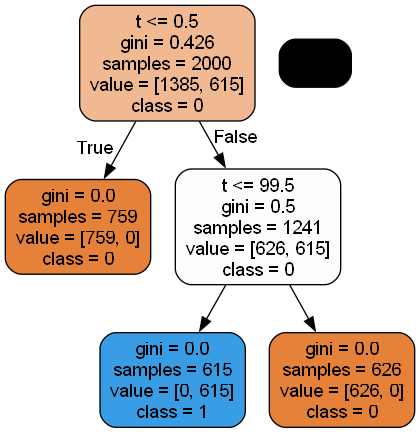

In [6]:
from sklearn import tree
import pydotplus
from IPython.display import Image

# visualize the decision tree - almost the same as in the introduction of the paper (here split values are <= 0.5 and <= 99.5 instead of < 0 and < 100)
dot_data = tree.export_graphviz(clf, out_file=None, 
                    feature_names=pred_atts, # attributes names
                    class_names=["0", "1"], # class labels
                    filled=True, rounded=True)  
graph = pydotplus.graph_from_dot_data(dot_data)  
Image(graph.create_png())

In [7]:
# DT embedding
df_code = dautils.Encode(nominal=[], ordinal=[target], decode={})
df_code.fit_transform(df)

,t1,t2,t,y
0,-88,47,-41,0
1,85,44,129,0
2,20,163,183,0
3,-20,45,25,1
4,-153,49,-104,0
...,...,...,...,...
1995,-3,80,77,1
1996,87,60,147,0
1997,-179,71,-108,0
1998,-183,95,-88,0


### Explain tree with ReasonX

In [8]:
# initialise ReasonX
r = reasonx.ReasonX(pred_atts, target, df_code, verbose=2) # verbose=2 high verbosity
r.model(clf)

In [9]:
# factual rule on a fully-specified instance
r.instance('F', label=1)
r.constraint("F.t1 = -10, F.t2 = 20")
r.solveopt()

---
Answer constraint: F.t1= -10.0,F.t2=20.0,F.t>0.5,F.t<=99.5
Rule satisfied by F: IF F.t>0.5,F.t<=99.5 THEN 1 [1.0000, 0.3075]


In [10]:
# factual rule on an under-specified instance
r.reset(keep_model=True)
r.instance('F', label=1)
r.constraint("F.t=F.t1+F.t2, F.t1 = -10")
r.solveopt()

---
Answer constraint: F.t1= -10.0,F.t2>10.5,F.t2<=109.5,F.t= -10.0+F.t2
Rule satisfied by F: IF F.t>0.5,F.t<=99.5 THEN 1 [1.0000, 0.3075]


In [11]:
# project over t2
r.solveopt(project=['F.t2'])

---
Answer constraint: F.t2>10.5,F.t2<=109.5


In [12]:
if assertion_check:
    assert r.answers() == ['F.t2>10.5,F.t2<=109.5']

In [13]:
# contrastive rule with fidelity
r.instance('CE', label=0, minconf=0.8)
r.constraint("CE.t=CE.t1+CE.t2, CE.t1=F.t1")
r.solveopt(project=["CE"])

---
Answer constraint: CE.t1= -10.0,CE.t2<=10.5,CE.t= -10.0+CE.t2
Contrastive rule satisfied by CE: IF Answer constraint THEN 0 [1.0000]
Rule satisfied by CE: IF CE.t<=0.5 THEN 0 [1.0000, 0.3795]
---
Answer constraint: CE.t1= -10.0,CE.t2>109.5,CE.t= -10.0+CE.t2
Contrastive rule satisfied by CE: IF Answer constraint THEN 0 [1.0000]
Rule satisfied by CE: IF CE.t>99.5 THEN 0 [1.0000, 0.3130]


In [14]:
# project over t2
r.solveopt(project=["CE.t2"])

---
Answer constraint: CE.t2<=10.5
---
Answer constraint: CE.t2>109.5


In [15]:
if assertion_check:
    assert r.answers() == ['CE.t2<=10.5', 'CE.t2>109.5']

In [16]:
# minimal contrastive rule with fidelity and minimized value
r.solveopt(minimize='l1norm(F, CE)', project=["CE"])

---
Answer constraint: CE.t1= -10.0,CE.t2=10.5,CE.t=0.5
Contrastive rule satisfied by CE: IF Answer constraint THEN 0 [1.0000]
Min value:0.0000
Rule satisfied by CE: IF CE.t<=0.5 THEN 0 [1.0000, 0.3795]
---
Answer constraint: CE.t1= -10.0,CE.t2=109.5,CE.t=99.5
Contrastive rule satisfied by CE: IF Answer constraint THEN 0 [1.0000]
Min value:0.0000
Rule satisfied by CE: IF CE.t>99.5 THEN 0 [1.0000, 0.3130]


In [17]:
if assertion_check:
    assert r.answers() == ['CE.t1= -10.0,CE.t2=10.5,CE.t=0.5', 'CE.t1= -10.0,CE.t2=109.5,CE.t=99.5']